## Exploratory Data Analysis

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import hashlib
from PIL import Image

In [2]:
# Set base directrory
base_dir = "/kaggle/input/competitions/cassava-leaf-disease-classification"

In [3]:
with open("/kaggle/input/competitions/cassava-leaf-disease-classification/label_num_to_disease_map.json") as file:
    print("yes")

yes


In [4]:
# load and inspect label map
with open(os.path.join(base_dir, "label_num_to_disease_map.json")) as file:
    map_classes = json.loads(file.read())
    map_classes = {int(k): v for k, v in map_classes.items()}

# Display the mapping
print("Class Mapping : ")
print(json.dumps(map_classes, indent=4))

# Here there are 5 classes where shown in bellow.

Class Mapping : 
{
    "0": "Cassava Bacterial Blight (CBB)",
    "1": "Cassava Brown Streak Disease (CBSD)",
    "2": "Cassava Green Mottle (CGM)",
    "3": "Cassava Mosaic Disease (CMD)",
    "4": "Healthy"
}


In [5]:
input_files = os.listdir(os.path.join(base_dir, "train_images"))
print(f"Number of train images : {len(input_files)}")

Number of train images : 21397


In [6]:
# step -3 : load train.csv and add a human-readable class name based on the mapping
df_train = pd.read_csv(os.path.join(base_dir, "train.csv"))
df_train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [7]:
df_train["class_name"] = df_train["label"].map(map_classes)
df_train

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


In [8]:
df_train["class_name"].value_counts()

class_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64

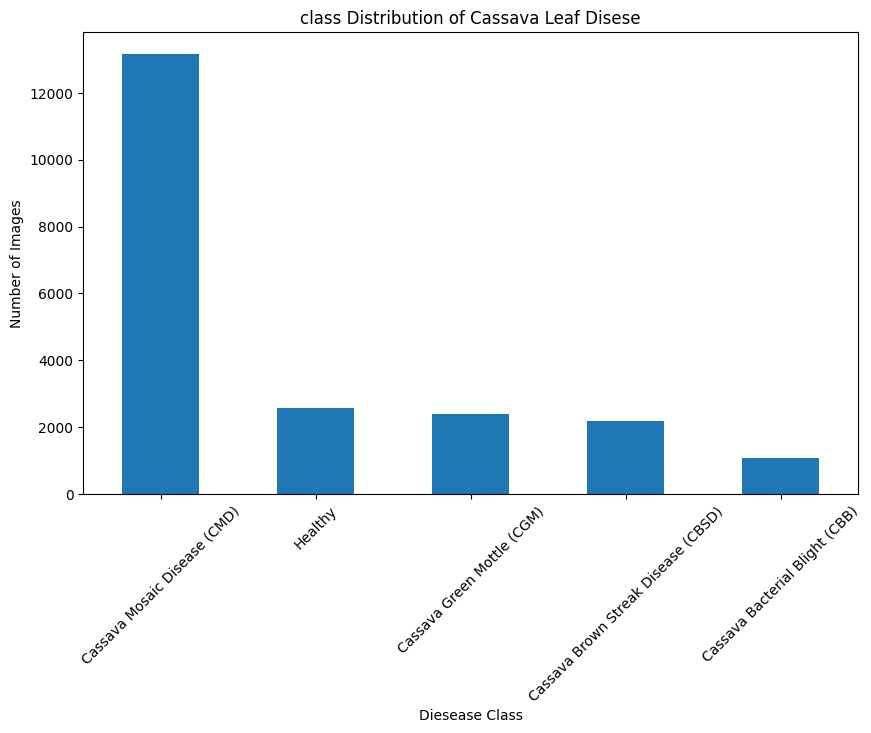

In [9]:
# check distribution 
class_distribution = df_train["class_name"].value_counts()

# plot the distribution
plt.figure(figsize=(10,6))
class_distribution.plot(kind="bar")
plt.title("class Distribution of Cassava Leaf Disese")
plt.ylabel("Number of Images")
plt.xlabel("Diesease Class")
plt.xticks(rotation=45)
plt.show()

When we use techniques like transfer learning, you dont need to balance the data, Internally model will handle. (In pre trained model)

but when you build the model scratch then we need to somthing to do for Imbalance data

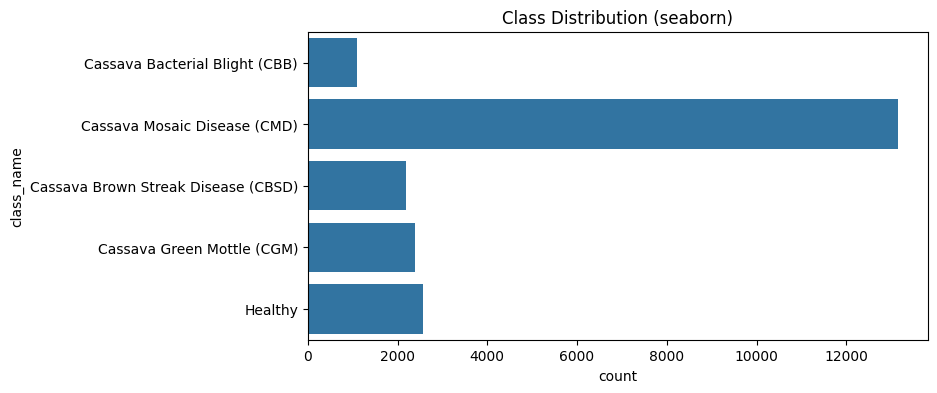

In [9]:
# countplot visualization
plt.figure(figsize=(8,4))
sns.countplot(y="class_name", data=df_train)
plt.title("Class Distribution (seaborn)")
plt.show()

In [11]:
# Show data info and summary statistics
print("Dataset Info : ")
print(df_train.info())

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    21397 non-null  object
 1   label       21397 non-null  int64 
 2   class_name  21397 non-null  object
dtypes: int64(1), object(2)
memory usage: 501.6+ KB
None


### Image

Lets check the shape of images.

Images - 50*50 (Very small pixels)

It doesn't make any sense to upscale to 224*224 (we mess up information)

If images 600*600 resize to may be 224*224

500*500

Image size distribution you need to tune you resize image size

In [11]:
# Analyze image shapes (size diemensions) for a sample of 1000 images
# Dictionary to store image shapes and their counts
img_shapes = {}

for image_name in os.listdir(os.path.join(base_dir, "train_images"))[:1000]:
    image = cv2.imread(os.path.join(base_dir, "train_images", image_name))
    img_shapes[image.shape] = img_shapes.get(image.shape, 0) + 1

# dispay image shape
print("Sample Image shapes and their frequencies (from 1000 images):")
print(img_shapes)

Sample Image shapes and their frequencies (from 1000 images):
{(600, 800, 3): 1000}


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from tqdm import tqdm

# Dataset Path
image_folder = "/kaggle/input/competitions/cassava-leaf-disease-classification/train_images"

In [13]:
# Check Image Formats
formats = Counter()

for image_name in tqdm(os.listdir(image_folder), desc="Checking Image Formats"):

    image_path = os.path.join(image_folder, image_name)

    try:
        with Image.open(image_path) as img:
            formats[img.format] += 1
    except Exception:
        pass

print("Image Formats")
print("-" * 30)

for fmt, count in formats.items():
    print(f"{fmt}: {count}")

Checking Image Formats: 100%|██████████| 21397/21397 [02:53<00:00, 123.10it/s]

Image Formats
------------------------------
JPEG: 21397


In [ ]:
# Check Corrupted Images
corrupted_images = []

for image_name in tqdm(os.listdir(image_folder), desc="Checking Corrupted Images"):

    image_path = os.path.join(image_folder, image_name)

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception:
        corrupted_images.append(image_name)

print(f"Total Corrupted Images : {len(corrupted_images)}")

if corrupted_images:
    print(corrupted_images[:10])

In [ ]:
# Brightness Distribution
brightness = []

for image_name in tqdm(os.listdir(image_folder), desc="Calculating Brightness"):

    image_path = os.path.join(image_folder, image_name)

    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness.append(gray.mean())

In [ ]:
# Plot Brightness Distribution
plt.figure(figsize=(10,5))

plt.hist(brightness,
         bins=30,
         edgecolor="black")

plt.title("Brightness Distribution")
plt.xlabel("Average Brightness")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
# Blur Detection
def variance_of_laplacian(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()


blur_scores = []

for image_name in tqdm(os.listdir(image_folder), desc="Calculating Blur Score"):

    image_path = os.path.join(image_folder, image_name)

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    blur_scores.append(variance_of_laplacian(gray))

In [ ]:
# Plot Blur Distribution
plt.figure(figsize=(10,5))

plt.hist(blur_scores,
         bins=30,
         edgecolor="black")

plt.title("Blur Score Distribution")
plt.xlabel("Variance of Laplacian")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
threshold = 100

blurry_images = []

for image_name in tqdm(os.listdir(image_folder), desc="Finding Blurry Images"):

    image_path = os.path.join(image_folder, image_name)

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    score = variance_of_laplacian(gray)

    if score < threshold:
        blurry_images.append((image_name, score))

print(f"Total Blurry Images : {len(blurry_images)}")

print("\nFirst 10 Blurry Images:")

for img_name, score in blurry_images[:10]:
    print(f"{img_name} --> {score:.2f}")

In [9]:
def plot_sample_images(class_id, num_images=9):
    """
    PLot sample images from a specific class in a 3x3 grid

    parameters : 
    class_id (int): The class label to filter images.
    num_images (int): The no. of images to plot
    """
    # Filter images for specified class
    class_images = df_train[df_train["label"] == class_id]
    num_images = min(len(class_images), num_images) # adjust if fewer images then 

    plt.figure(figsize=(10, 10))
    images = class_images.sample(num_images)

    # plot images on 3x3 grid
    for i, (_, row) in enumerate(images.iterrows()):
        img_path = os.path.join(base_dir, "train_images", row["image_id"])
        img = Image.open(img_path)
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(map_classes[class_id]) # use class name for the title
        plt.axis("off") # hide axis for better visualization

    plt.tight_layout()
    plt.show

In [1]:
plot_sample_images(4)

NameError: name 'plot_sample_images' is not defined

In [14]:
df_train.head()

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


### Duplicate Images

In [20]:
# Finding Duplicate images 
# Identify the exact duplicate images
def get_image_hash(image_path):
    """Generate an md5 for the images to find Duplicate images"""
    with open(image_path, "rb") as f :
        file_hash = hashlib.md5(f.read()).hexdigest()
    return file_hash


# Directinary to store image hashes and thair file names
image_hashes = {}

# check for duplicatw images
duplicate_images = []
for image_name in os.listdir(os.path.join(base_dir, "train_images")):
    image_path = os.path.join(base_dir, "train_images", image_name)
    image_hash = get_image_hash(image_path)

    if image_hash in image_hashes:
        duplicate_images.append((image_name, image_hashes[image_hash])) # If image is duplicate then add into duplicate_images
    else:
        image_hashes[image_hash] = image_name # store to the hash

print(f"Found {len(duplicate_images)} exact duplicate images. ")
for dup in duplicate_images:
    print(f"Duplicate pair : {dup[0]} and {dup[1]}")


Found 0 exact duplicate images. 


In [10]:
df_train.head()

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


## Train Test and Validation split

In [11]:
# Before doing train test and validation split, we do add image whole directory to the dataframe, so when we use tensorflow, it will easy to do modeling
# Dataset Path
image_folder = "/kaggle/input/competitions/cassava-leaf-disease-classification/train_images"
df_train["image_path"] = df_train["image_id"].apply(
    lambda x : os.path.join(image_folder, x)
)

In [12]:
# I want to this order
desired_order = ['image_id', 'image_path', 'label', 'class_name']
df_train = df_train.reindex(columns=desired_order)

In [13]:
df_train.head()

,image_id,image_path,label,class_name
0,1000015157.jpg,/kaggle/input/competitions/cassava-leaf-diseas...,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,/kaggle/input/competitions/cassava-leaf-diseas...,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,/kaggle/input/competitions/cassava-leaf-diseas...,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,/kaggle/input/competitions/cassava-leaf-diseas...,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,/kaggle/input/competitions/cassava-leaf-diseas...,3,Cassava Mosaic Disease (CMD)


In [14]:
# train test split
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df_train,
    test_size=0.20,
    random_state=42,
    stratify=df_train["label"]
)

In [15]:
# in that test (temp_df) to split validation and test split
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

In [16]:
# checking size of all the train_df, valid_df, test_df
print("Train :", len(train_df))
print("Validation :", len(valid_df))
print("Test :", len(test_df))

Train : 17117
Validation : 2140
Test : 2140


In [17]:
# then veryfiy the class distribution
print(train_df["label"].value_counts())

print()

print(valid_df["label"].value_counts(normalize=True))

print()

print(test_df["label"].value_counts(normalize=True))

label
3    10526
4     2061
2     1909
1     1751
0      870
Name: count, dtype: int64

label
3    0.614953
4    0.120561
2    0.111682
1    0.102336
0    0.050467
Name: proportion, dtype: float64

label
3    0.614953
4    0.120561
2    0.111215
1    0.102336
0    0.050935
Name: proportion, dtype: float64


All class The percentages should be nearly identical.

## Save the model in working directotry

In [18]:
import os

os.makedirs("/kaggle/working/data_splits", exist_ok=True)

train_df.to_csv("/kaggle/working/data_splits/train_split.csv", index=False)
valid_df.to_csv("/kaggle/working/data_splits/valid_split.csv", index=False)
test_df.to_csv("/kaggle/working/data_splits/test_split.csv", index=False)

## TensorFlow Data Pipeline

In [18]:
import tensorflow as tf

# now we have to create tensorflow dataset
# since I already do splitting and added image_path into it so now 

# for train_df data
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values,
    train_df["label"].values
))

# for valid_df data
valid_ds = tf.data.Dataset.from_tensor_slices((
    valid_df["image_path"].values,
    valid_df["label"].values
))

# for test_df data
test_ds = tf.data.Dataset.from_tensor_slices((
    test_df["image_path"].values,
    test_df["label"].values
))

I0000 00:00:1783493856.317026      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783493856.323199      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [19]:
print(train_ds)
print(valid_ds)
print(test_ds)

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


### Create the Image Loading Function

In [33]:
IMAGE_SIZE = (224, 224)

def load_image(image_path, label):
    # read image
    image = tf.io.read_file(image_path)

    # Decode JPEG
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize
    image = tf.image.resize(image, IMAGE_SIZE)

    # Normalize
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

### Apply the Function and AUTOTUNE, Shuffle, batch and Prefetch

In [34]:
train_ds = (
    tf.data.Dataset.from_tensor_slices(
        (train_df["image_path"], train_df["label"])
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_df), seed=42)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    tf.data.Dataset.from_tensor_slices(
        (valid_df["image_path"], valid_df["label"])
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test_df["image_path"], test_df["label"])
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

### Displaying Image

In [35]:
# class_names = {
#     0: "CBB",
#     1: "CBSD",
#     2: "CGM",
#     3: "CMD",
#     4: "Healthy"
# }

# plt.figure(figsize=(12, 8))

# for images, labels in train_ds.take(1):

#     for i in range(9):

#         plt.subplot(3, 3, i + 1)

#         plt.imshow(images[i])

#         plt.title(class_names[int(labels[i])])

#         plt.axis("off")

# plt.tight_layout()
# plt.show()

KeyboardInterrupt: 

<Figure size 1200x800 with 0 Axes>

## Train a baseline model

In [43]:
from tensorflow.keras import layers, models

In [44]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1st convolution block
    layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same", input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    # 2nd convolution block
    layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    # 3rd convolution block
    layers.Conv2D(filters=128, kernel_size=(3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),

    # 4th conv
    # layers.Conv2D(filters=512, kernel_size=(3,3), activation="relu", padding="same"),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # output
    layers.Dense(5, activation="softmax"),
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,479,493 (196.38 MB)

 Trainable params: 51,478,021 (196.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [45]:
# Compilation
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
  2/535 ━━━━━━━━━━━━━━━━━━━━ 49s 93ms/step - accuracy: 0.2422 - loss: 3.3890   

I0000 00:00:1783487240.164736     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


535/535 ━━━━━━━━━━━━━━━━━━━━ 90s 101ms/step - accuracy: 0.5565 - loss: 1.3968 - val_accuracy: 0.5481 - val_loss: 1.2187
Epoch 2/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.6352 - loss: 1.0093 - val_accuracy: 0.5327 - val_loss: 1.2448
Epoch 3/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.6599 - loss: 0.9189 - val_accuracy: 0.6262 - val_loss: 0.9740
Epoch 4/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 81ms/step - accuracy: 0.6973 - loss: 0.8028 - val_accuracy: 0.6388 - val_loss: 2.3968
Epoch 5/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.7330 - loss: 0.7098 - val_accuracy: 0.6593 - val_loss: 0.9490
Epoch 6/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.7719 - loss: 0.6100 - val_accuracy: 0.6640 - val_loss: 0.9489
Epoch 7/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.8375 - loss: 0.4445 - val_accuracy: 0.6547 - val_loss: 1.5286
Epoch 8/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.9024 - loss: 0.2766 - val_accura

In [28]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.6575 - loss: 0.9442
Test Loss: 0.9442
Test Accuracy: 0.6575


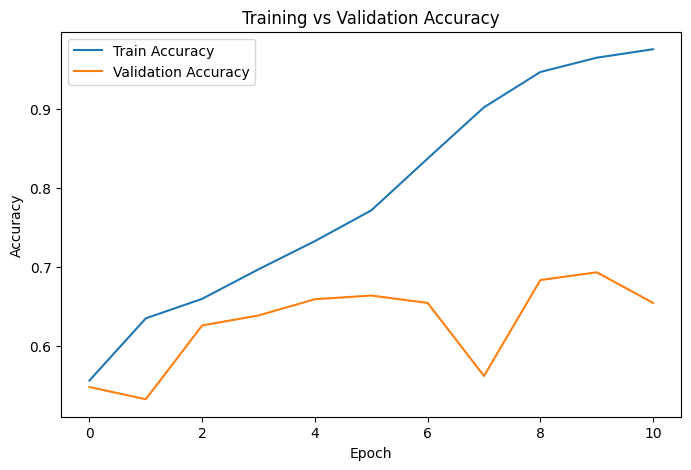

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

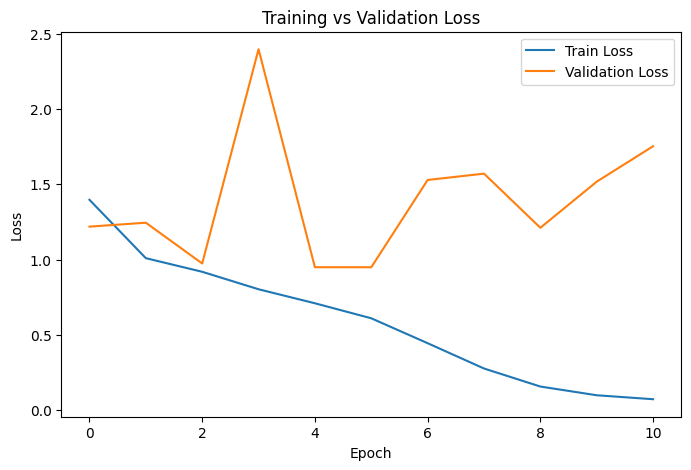

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [32]:
import numpy as np

# Predict probabilities
predictions = model.predict(test_ds)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step


In [33]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [34]:
print(y_true.shape)
print(y_pred.shape)

(2140,)
(2140,)


## Plot Confiusion Matrix

In [55]:
label_map = (
    train_df[["label", "class_name"]]
    .drop_duplicates()
    .sort_values("label")
)
label_map = dict(zip(label_map["label"], label_map["class_name"]))

print(label_map)

{0: 'Cassava Bacterial Blight (CBB)', 1: 'Cassava Brown Streak Disease (CBSD)', 2: 'Cassava Green Mottle (CGM)', 3: 'Cassava Mosaic Disease (CMD)', 4: 'Healthy'}


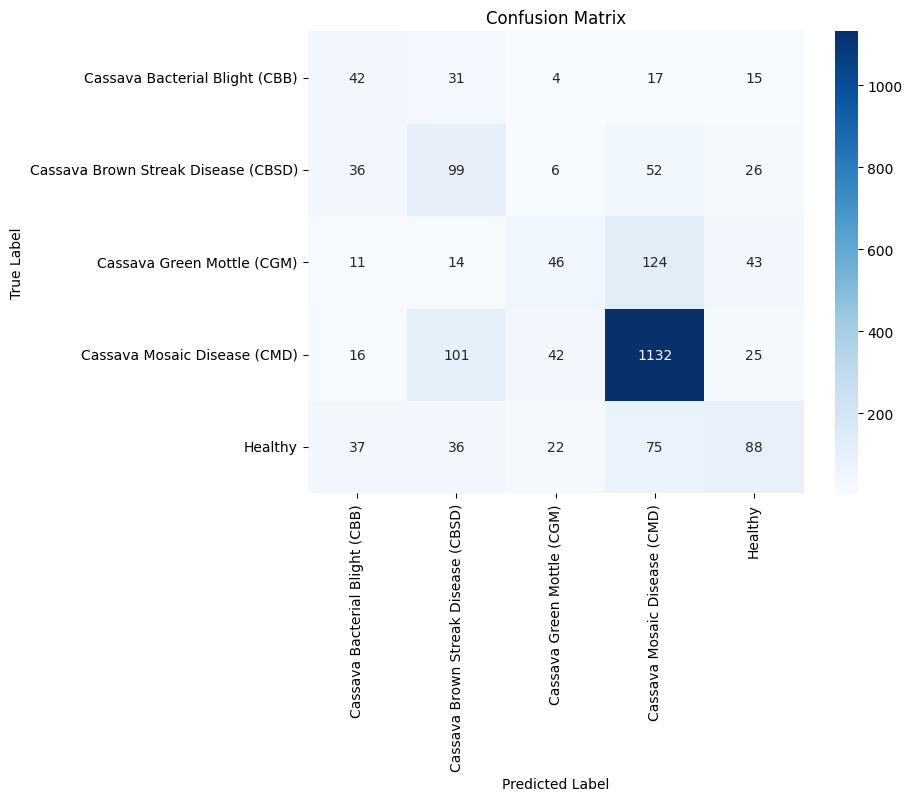

In [46]:
# label_map = {
#     0: "Cassava Bacterial Blight (CBB)",
#     1: "Cassava Brown Streak Disease (CBSD)",
#     2: "Cassava Green Mottle (CGM)",
#     3: "Cassava Mosaic Disease (CMD)",
#     4: "Healthy"
# }

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [48]:
# Now make a clasification report
from sklearn.metrics import classification_report

classification_report = classification_report(y_true, y_pred, target_names=list(label_map.values()))

print(classification_report)

                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.30      0.39      0.33       109
Cassava Brown Streak Disease (CBSD)       0.35      0.45      0.40       219
         Cassava Green Mottle (CGM)       0.38      0.19      0.26       238
       Cassava Mosaic Disease (CMD)       0.81      0.86      0.83      1316
                            Healthy       0.45      0.34      0.39       258

                           accuracy                           0.66      2140
                          macro avg       0.46      0.45      0.44      2140
                       weighted avg       0.64      0.66      0.65      2140



What is "Support"?
- Suppport means how many true samples of that class are in the test set.

For Example - : 
    Cassava Mosaic Disease (CMD)
    Support = 1316

    This means, There are 1316 CMD images in your test dataset.

Note -:

Support is not a performance metric—it's simply the number of test examples for that class.

### Precision
Example:

    CBB Precision = 0.30
    
    Imagine the model predicted 100 images as CBB.
    
    Only 30 were actually CBB.
    means correct is 30 and wrong is 70

### Recall
For CBB:

Recall = 0.39

There are 109 real CBB images.

The model correctly identified about:

109 × 0.39 ≈ 43 images

It missed the remaining:

109 − 43 = 66 images

### Macro Average
Macro Avg F1 = 0.44

Macro averaging treats every class equally, regardless of how many samples it has.

It computes the metric for each class and then takes the average.

This tells you:

"If every disease were equally important, how well does the model perform?"

Since the macro F1 is only 0.44, your model is not doing well across all classes.

## Data Augmentation

In [46]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [47]:
# Apply augmentation
IMAGE_SIZE=(224, 224)

def load_image(image_path, label):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

# function for augmentation
def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label



In [48]:
# Then update pipeline
train_ds_aug = (
    tf.data.Dataset.from_tensor_slices((
            train_df["image_path"],
            train_df["label"]
        ))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_df), seed=42)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [49]:
# Verify the Augmentation
# plt.figure(figsize=(5, 5))

# for images, labels in train_ds_aug.take(1):

#     for i in range(9):
#         plt.subplot(3, 3, i + 1)
#         plt.imshow(images[i])
#         plt.axis("off")

# plt.tight_layout()
# plt.show()

In [50]:
# callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/kaggle/working/best_baseline_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Now all callbacks in one 
callbacks = [
    early_stop,
    checkpoint,
    reduce_lr
]

In [51]:
history_aug = model.fit(
    train_ds_aug,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4807 - loss: 1.7317
Epoch 1: val_loss improved from None to 1.27631, saving model to /kaggle/working/best_baseline_model.keras

Epoch 1: finished saving model to /kaggle/working/best_baseline_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 163s 103ms/step - accuracy: 0.5520 - loss: 1.3843 - val_accuracy: 0.5103 - val_loss: 1.2763 - learning_rate: 0.0010
Epoch 2/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6323 - loss: 1.0397
Epoch 2: val_loss did not improve from 1.27631
535/535 ━━━━━━━━━━━━━━━━━━━━ 141s 80ms/step - accuracy: 0.6383 - loss: 1.0051 - val_accuracy: 0.3879 - val_loss: 1.3816 - learning_rate: 0.0010
Epoch 3/20
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6668 - loss: 0.9122
Epoch 3: val_loss improved from 1.27631 to 1.10526, saving model to /kaggle/working/best_baseline_model.keras

Epoch 3: finished saving model to /kaggle/working/best_baseline_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 144

In [52]:
# Evaluate the augmented model
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.7743 - loss: 0.6164
Test Loss: 0.6164
Test Accuracy: 0.7743


In [56]:
# Classification Report
import numpy as np
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(label_map.values())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.44      0.34      0.38       109
Cassava Brown Streak Disease (CBSD)       0.62      0.63      0.63       219
         Cassava Green Mottle (CGM)       0.63      0.57      0.60       238
       Cassava Mosaic Disease (CMD)       0.92      0.89      0.91      1316
                            Healthy       0.49      0.66      0.56       258

                           accuracy                           0.77      2140
                          macro avg       0.62      0.62      0.62      2140
                       weighted avg       0.78      0.77      0.78      2140



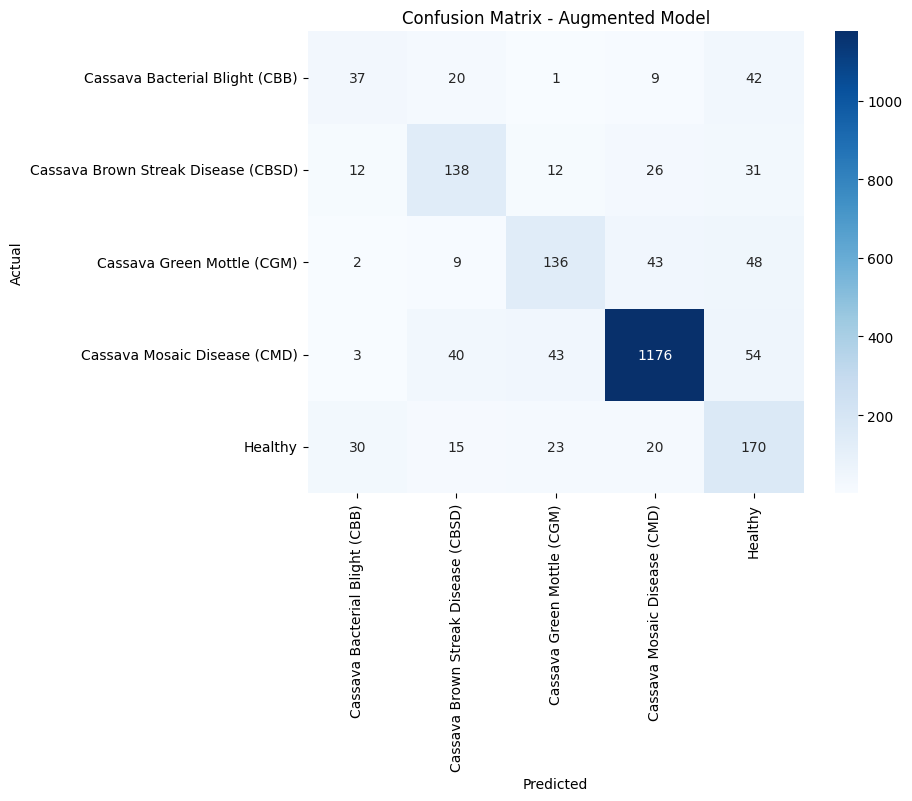

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Augmented Model")
plt.show()

## Compare Training & Validation Accuracy 

history → Baseline CNN training history
history_aug → Augmented CNN training history

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Baseline
plt.plot(
    history.history["accuracy"],
    label="Baseline Train Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Baseline Validation Accuracy",
    linewidth=2
)

# Augmented
plt.plot(
    history_aug.history["accuracy"],
    label="Augmented Train Accuracy",
    linewidth=2
)

plt.plot(
    history_aug.history["val_accuracy"],
    label="Augmented Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Baseline vs Augmented Model Accuracy", fontsize=14)

plt.grid(True)
plt.legend()

plt.show()

NameError: name 'history' is not defined

<Figure size 1000x600 with 0 Axes>

## Compare Training & Validation Loss

In [ ]:
plt.figure(figsize=(10, 6))

# Baseline
plt.plot(
    history.history["loss"],
    label="Baseline Train Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Baseline Validation Loss",
    linewidth=2
)

# Augmented
plt.plot(
    history_aug.history["loss"],
    label="Augmented Train Loss",
    linewidth=2
)

plt.plot(
    history_aug.history["val_loss"],
    label="Augmented Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Baseline vs Augmented Model Loss", fontsize=14)

plt.grid(True)
plt.legend()

plt.show()

In [62]:
model.save("/kaggle/working/best_baseline_model.keras")

## Try Transfer Learning in EfficientNetB0

In [68]:
# Image Loading Function
IMAGE_SIZE = (224, 224)

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)

    # IMPORTANT:
    # Keep pixel values as float32.
    # EfficientNet in tf.keras already contains a Rescaling layer.
    image = tf.cast(image, tf.float32)

    return image, label

In [70]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def augment(image, label):

    image = data_augmentation(image, training=True)

    return image, label

In [71]:
BATCH_SIZE = 32

train_ds_eff = (
    tf.data.Dataset.from_tensor_slices(
        (
            train_df["image_path"].values,
            train_df["label"].values
        )
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_df), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [72]:
valid_ds_eff = (
    tf.data.Dataset.from_tensor_slices(
        (
            valid_df["image_path"].values,
            valid_df["label"].values
        )
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [73]:
test_ds_eff = (
    tf.data.Dataset.from_tensor_slices(
        (
            test_df["image_path"].values,
            test_df["label"].values
        )
    )
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [74]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

In [75]:
base_model.trainable = False

In [76]:
# Build the Model

inputs = layers.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [77]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [78]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [79]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/models/efficientnet_b0.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stop,
    checkpoint,
    reduce_lr
]

In [80]:
history_eff = model.fit(
    train_ds_eff,
    validation_data=valid_ds_eff,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6649 - loss: 0.9408
Epoch 1: val_loss improved from None to 0.83476, saving model to /kaggle/working/models/efficientnet_b0.keras

Epoch 1: finished saving model to /kaggle/working/models/efficientnet_b0.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 174s 88ms/step - accuracy: 0.6877 - loss: 0.8523 - val_accuracy: 0.6958 - val_loss: 0.8348 - learning_rate: 0.0010
Epoch 2/15
535/535 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7242 - loss: 0.7633
Epoch 2: val_loss improved from 0.83476 to 0.77745, saving model to /kaggle/working/models/efficientnet_b0.keras

Epoch 2: finished saving model to /kaggle/working/models/efficientnet_b0.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 128s 46ms/step - accuracy: 0.7232 - loss: 0.7589 - val_accuracy: 0.7192 - val_loss: 0.7774 - learning_rate: 0.0010
Epoch 3/15
534/535 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7294 - loss: 0.7334
Epoch 3: val_loss improved from 0.77745 to 0.75847, saving model to 

In [81]:
test_loss, test_acc = model.evaluate(test_ds_eff)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7280 - loss: 0.7645
Test Loss : 0.7644823789596558
Test Accuracy : 0.7280373573303223


In [82]:
predictions = model.predict(test_ds_eff)
y_pred = np.argmax(predictions, axis=1)

y_true = []

for images, labels in test_ds_eff:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(label_map.values())
))

67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.45      0.52      0.49       109
Cassava Brown Streak Disease (CBSD)       0.58      0.50      0.54       219
         Cassava Green Mottle (CGM)       0.59      0.39      0.47       238
       Cassava Mosaic Disease (CMD)       0.88      0.86      0.87      1316
                            Healthy       0.43      0.64      0.51       258

                           accuracy                           0.73      2140
                          macro avg       0.59      0.58      0.58      2140
                       weighted avg       0.74      0.73      0.73      2140



## Transfer Learning Fine Tuening